In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
import joblib

In [2]:
dataset="German-House-Prices.csv"
df = pd.read_csv(dataset)
df.head()

,Unnamed:_0,Price,Type,Living_space,Lot,Usable_area,Free_of_Relation,Rooms,Bedrooms,Bathrooms,...,Energy_source,Energy_certificate,Energy_certificate_type,Energy_consumption,Energy_efficiency_class,State,City,Place,Garages,Garagetype
0,0,498000.0,Multiple dwelling,106.00,229.0,NaN,01.10.2020,5.5,3.0,1.0,...,Gas,available,demand certificate,NaN,D,Baden-Wrttemberg,Bodenseekreis,Bermatingen,2.0,Parking lot
1,1,495000.0,Mid-terrace house,140.93,517.0,20.00,01.01.2021,6.0,3.0,2.0,...,NaN,not required by law,NaN,NaN,NaN,Baden-Wrttemberg,Konstanz (Kreis),Engen,7.0,Parking lot
2,2,749000.0,Farmhouse,162.89,82.0,37.62,01.07.2020,5.0,3.0,2.0,...,"Fernwrme, Bioenergie",available,demand certificate,NaN,B,Baden-Wrttemberg,Esslingen (Kreis),Ostfildern,1.0,Garage
3,3,259000.0,Farmhouse,140.00,814.0,NaN,nach Vereinbarung,4.0,NaN,2.0,...,Strom,available,demand certificate,NaN,G,Baden-Wrttemberg,Waldshut (Kreis),Bonndorf im Schwarzwald,1.0,Garage
4,4,469000.0,Multiple dwelling,115.00,244.0,NaN,sofort,4.5,2.0,1.0,...,l,available,demand certificate,NaN,F,Baden-Wrttemberg,Esslingen (Kreis),Leinfelden-Echterdingen,1.0,Garage


In [3]:
df.shape

(10552, 26)

In [4]:
df.nunique()

Unnamed:_0                 10552
Price                       1411
Type                          11
Living_space                1867
Lot                         2526
Usable_area                 1012
Free_of_Relation             704
Rooms                         72
Bedrooms                      32
Bathrooms                     28
Floors                        10
Year_built                   292
Furnishing_quality             4
Year_renovated                67
Condition                     10
Heating                       13
Energy_source                104
Energy_certificate             3
Energy_certificate_type        2
Energy_consumption          1423
Energy_efficiency_class        9
State                         16
City                         534
Place                       4760
Garages                       37
Garagetype                     7
dtype: int64

In [5]:
df.dtypes

Unnamed:_0                   int64
Price                      float64
Type                        object
Living_space               float64
Lot                        float64
Usable_area                float64
Free_of_Relation            object
Rooms                      float64
Bedrooms                   float64
Bathrooms                  float64
Floors                     float64
Year_built                 float64
Furnishing_quality          object
Year_renovated             float64
Condition                   object
Heating                     object
Energy_source               object
Energy_certificate          object
Energy_certificate_type     object
Energy_consumption         float64
Energy_efficiency_class     object
State                       object
City                        object
Place                       object
Garages                    float64
Garagetype                  object
dtype: object

In [6]:
df.describe()

,Unnamed:_0,Price,Living_space,Lot,Usable_area,Rooms,Bedrooms,Bathrooms,Floors,Year_built,Year_renovated,Energy_consumption,Garages
count,10552.000000,1.055200e+04,10552.000000,10552.000000,5568.000000,10552.000000,6878.000000,8751.000000,7888.000000,9858.000000,5349.000000,2433.000000,8592.000000
mean,5275.500000,5.566851e+05,216.721008,1491.659004,134.300424,7.388978,4.169817,2.308993,2.283976,1958.821465,2010.706300,117.663111,2.698673
std,3046.244354,6.087410e+05,172.421321,8582.361675,188.814089,5.378126,2.577169,1.742330,0.821288,55.958072,10.548651,54.023207,3.195068
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1300.000000,1900.000000,5.100000,1.000000
25%,2637.750000,2.500000e+05,130.000000,370.000000,48.000000,5.000000,3.000000,1.000000,2.000000,1935.000000,2006.000000,83.170000,1.000000
50%,5275.500000,4.052150e+05,176.775000,656.500000,80.000000,6.000000,4.000000,2.000000,2.000000,1971.000000,2015.000000,112.700000,2.000000
75%,7913.250000,6.550000e+05,250.000000,1047.000000,150.250000,8.000000,5.000000,3.000000,3.000000,1996.000000,2018.000000,146.000000,3.000000
max,10551.000000,1.300000e+07,5600.000000,547087.000000,4034.000000,170.000000,61.000000,44.000000,13.000000,2022.000000,2206.000000,503.940000,70.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10552 entries, 0 to 10551
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed:_0               10552 non-null  int64  
 1   Price                    10552 non-null  float64
 2   Type                     10150 non-null  object 
 3   Living_space             10552 non-null  float64
 4   Lot                      10552 non-null  float64
 5   Usable_area              5568 non-null   float64
 6   Free_of_Relation         6983 non-null   object 
 7   Rooms                    10552 non-null  float64
 8   Bedrooms                 6878 non-null   float64
 9   Bathrooms                8751 non-null   float64
 10  Floors                   7888 non-null   float64
 11  Year_built               9858 non-null   float64
 12  Furnishing_quality       7826 non-null   object 
 13  Year_renovated           5349 non-null   float64
 14  Condition             

In [8]:
df.isnull().sum()

Unnamed:_0                    0
Price                         0
Type                        402
Living_space                  0
Lot                           0
Usable_area                4984
Free_of_Relation           3569
Rooms                         0
Bedrooms                   3674
Bathrooms                  1801
Floors                     2664
Year_built                  694
Furnishing_quality         2726
Year_renovated             5203
Condition                   323
Heating                     584
Energy_source              1227
Energy_certificate          755
Energy_certificate_type    3526
Energy_consumption         8119
Energy_efficiency_class    4819
State                         1
City                          1
Place                       290
Garages                    1960
Garagetype                 1960
dtype: int64

In [9]:
#drop unnecessary columns, and energy consumption as it has too many nulls
df1=df.drop(columns=['Unnamed:_0','Energy_consumption'])
df1.head()

,Price,Type,Living_space,Lot,Usable_area,Free_of_Relation,Rooms,Bedrooms,Bathrooms,Floors,...,Heating,Energy_source,Energy_certificate,Energy_certificate_type,Energy_efficiency_class,State,City,Place,Garages,Garagetype
0,498000.0,Multiple dwelling,106.00,229.0,NaN,01.10.2020,5.5,3.0,1.0,2.0,...,central heating,Gas,available,demand certificate,D,Baden-Wrttemberg,Bodenseekreis,Bermatingen,2.0,Parking lot
1,495000.0,Mid-terrace house,140.93,517.0,20.00,01.01.2021,6.0,3.0,2.0,NaN,...,stove heating,NaN,not required by law,NaN,NaN,Baden-Wrttemberg,Konstanz (Kreis),Engen,7.0,Parking lot
2,749000.0,Farmhouse,162.89,82.0,37.62,01.07.2020,5.0,3.0,2.0,4.0,...,stove heating,"Fernwrme, Bioenergie",available,demand certificate,B,Baden-Wrttemberg,Esslingen (Kreis),Ostfildern,1.0,Garage
3,259000.0,Farmhouse,140.00,814.0,NaN,nach Vereinbarung,4.0,NaN,2.0,2.0,...,central heating,Strom,available,demand certificate,G,Baden-Wrttemberg,Waldshut (Kreis),Bonndorf im Schwarzwald,1.0,Garage
4,469000.0,Multiple dwelling,115.00,244.0,NaN,sofort,4.5,2.0,1.0,NaN,...,central heating,l,available,demand certificate,F,Baden-Wrttemberg,Esslingen (Kreis),Leinfelden-Echterdingen,1.0,Garage


### Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df1,test_size=0.2,random_state=42)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (8441, 24)
Test shape: (2111, 24)


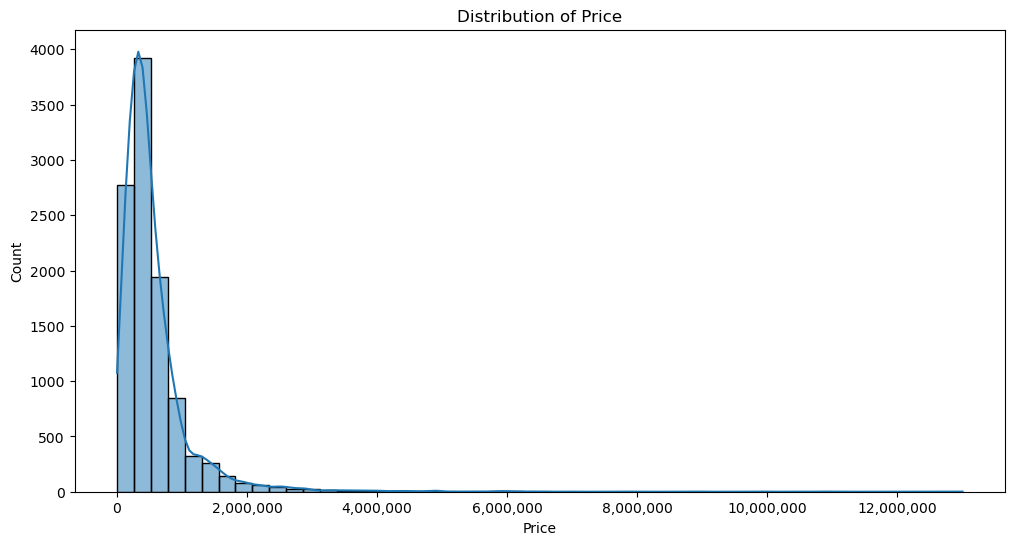

In [199]:

plt.figure(figsize=(12,6))
sns.histplot(y_test_new, bins=50, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")

# Format x-axis with commas
plt.gca().get_xaxis().set_major_formatter(
    mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.show()


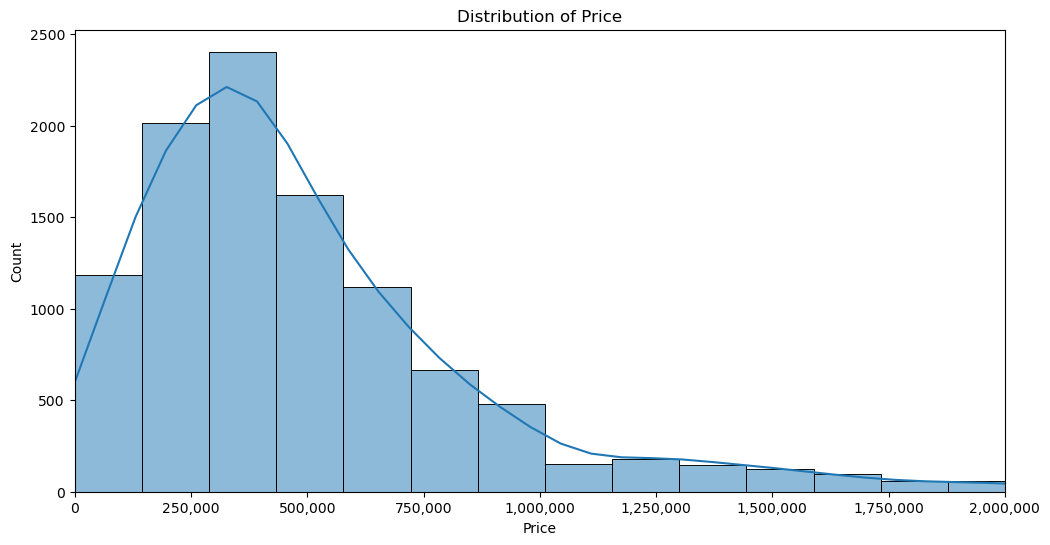

In [203]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.histplot(y_test_new, bins=90, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")

# Format x-axis with commas
plt.gca().get_xaxis().set_major_formatter(
    mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

# Limit x-axis to 5,000,000
plt.xlim(0,2000000)

plt.show()


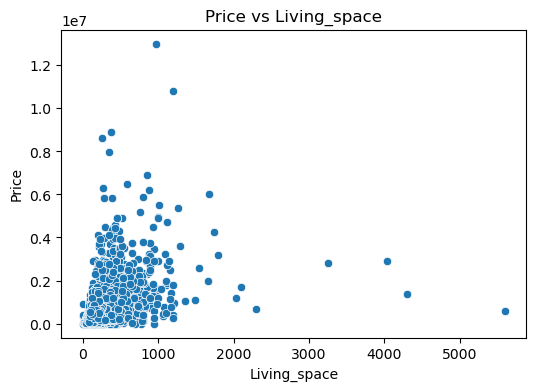

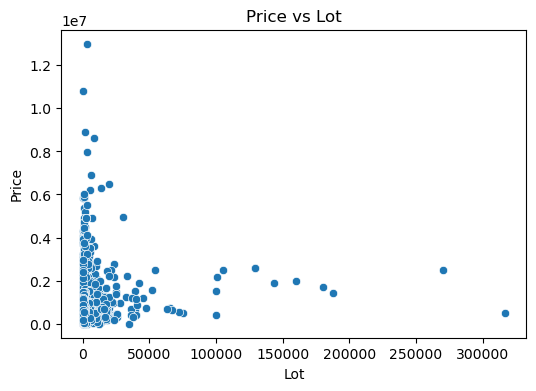

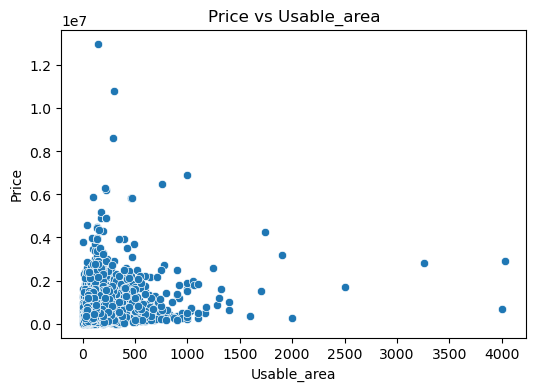

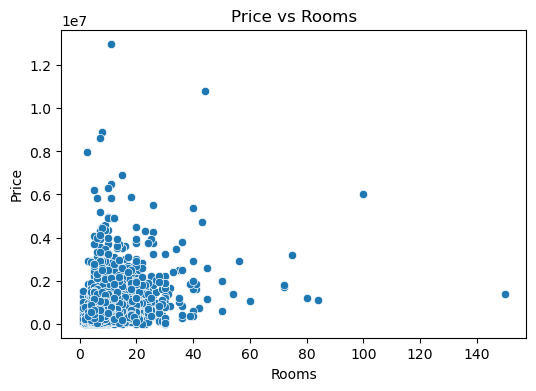

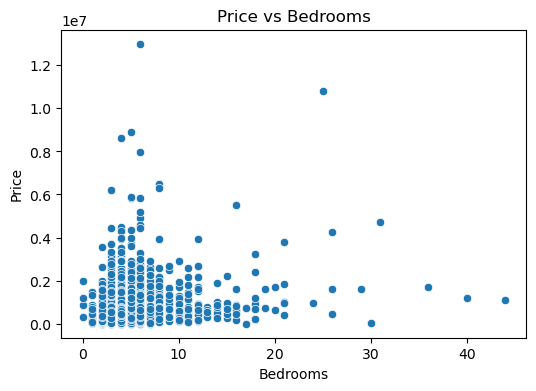

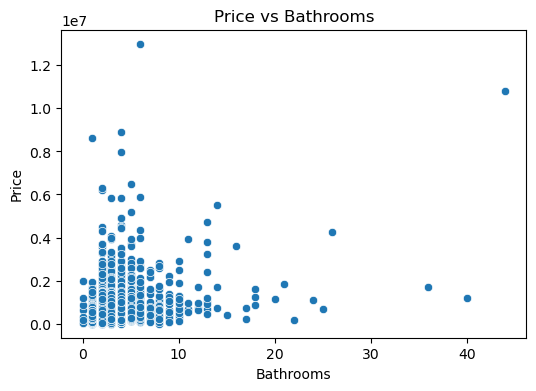

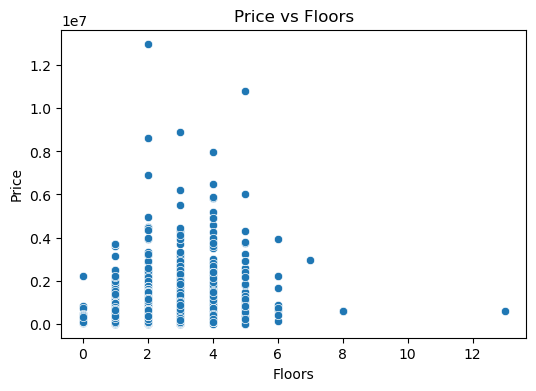

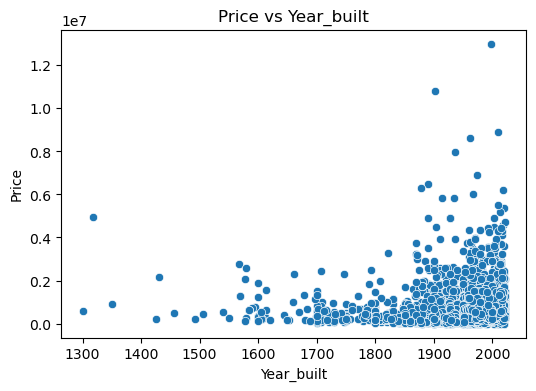

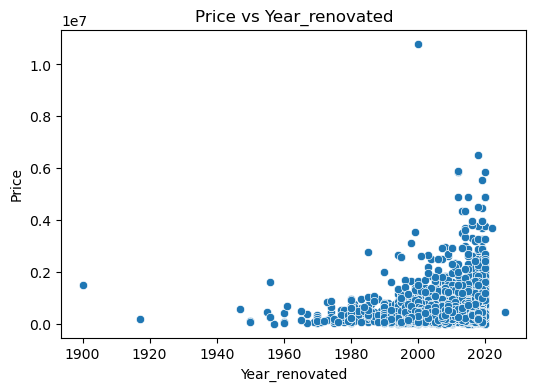

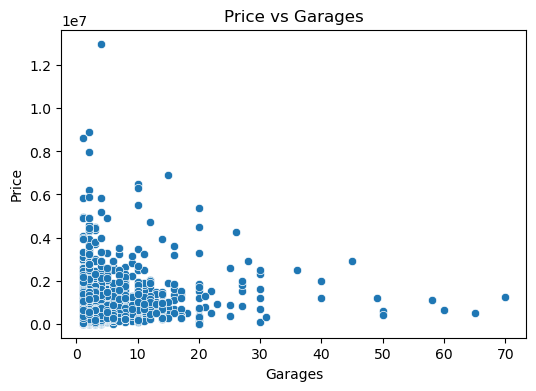

In [12]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols.remove('Price')  # exclude target

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=train_df[col], y=train_df['Price'])
    plt.title(f"Price vs {col}")
    plt.show()


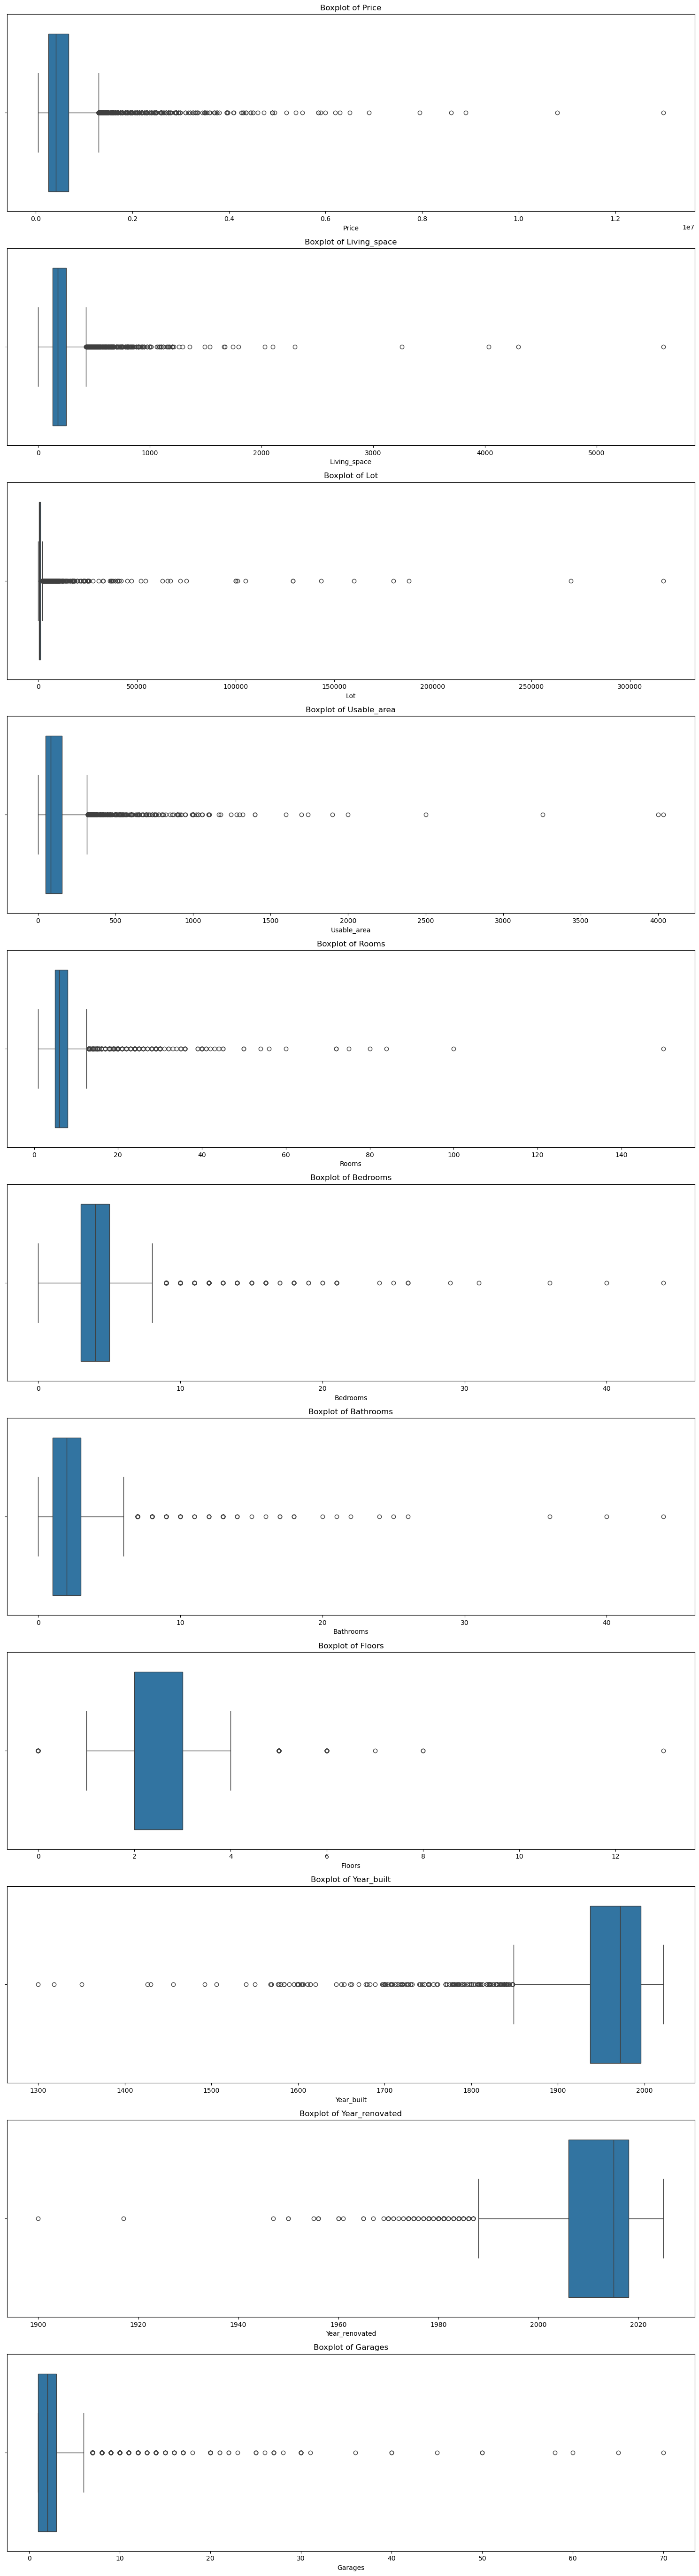

In [42]:

# Select numerical features
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Plot boxplots for numerical features
plt.figure(figsize=(15, 5*len(numeric_cols)))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


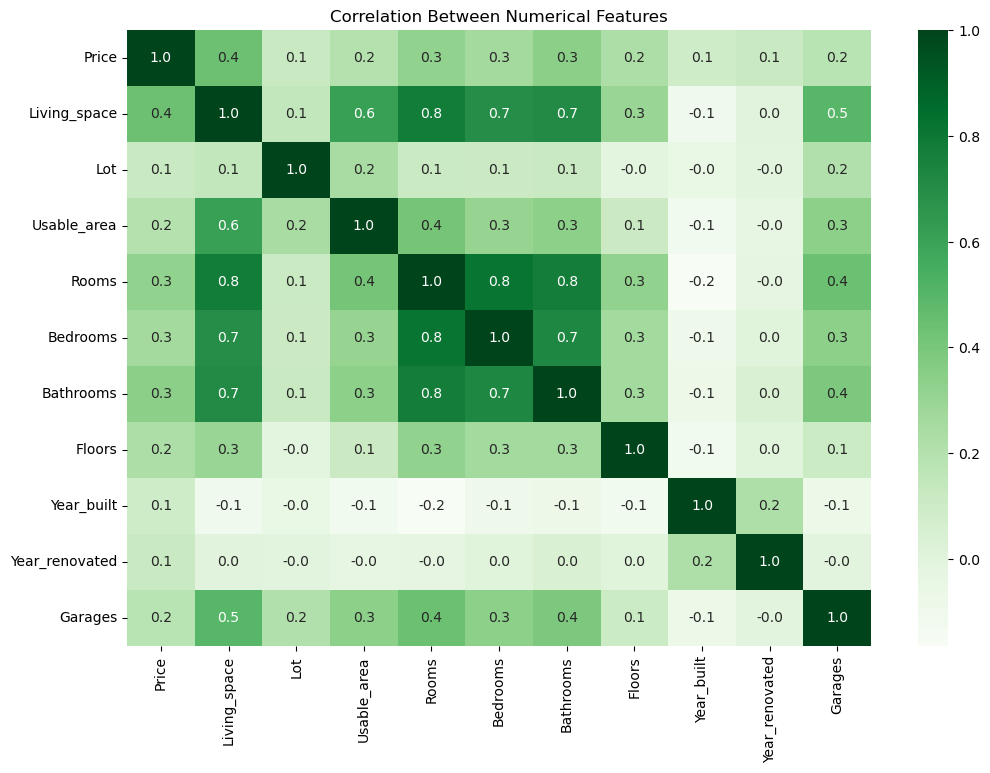

In [51]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(12,8))
sns.heatmap(train_df[numeric_cols].corr(),annot=True, cmap='Greens', fmt='.1f')
plt.title('Correlation Between Numerical Features')
plt.show()

In [15]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numeric_cols:
    print(f"{col:20} | Min: {train_df[col].min():8}    | Max: {train_df[col].max():8}")

Price                | Min:      0.0    | Max: 13000000.0
Living_space         | Min:      0.0    | Max:   5600.0
Lot                  | Min:      0.0    | Max: 317000.0
Usable_area          | Min:      0.0    | Max:   4034.0
Rooms                | Min:      1.0    | Max:    150.0
Bedrooms             | Min:      0.0    | Max:     44.0
Bathrooms            | Min:      0.0    | Max:     44.0
Floors               | Min:      0.0    | Max:     13.0
Year_built           | Min:   1300.0    | Max:   2022.0
Year_renovated       | Min:   1900.0    | Max:   2026.0
Garages              | Min:      1.0    | Max:     70.0


In [17]:
invalid_zero_columns = ['Price', 'Living_space', 'Lot', 'Usable_area']

train_df = train_df[~(train_df[invalid_zero_columns] == 0).any(axis=1)]

for col in invalid_zero_columns:
    print(f"{col:15} | Min: {train_df[col].min():8} | Max: {train_df[col].max():8}")


Price           | Min:      1.0 | Max: 13000000.0
Living_space    | Min:      1.0 | Max:   5600.0
Lot             | Min:     0.16 | Max: 317000.0
Usable_area     | Min:      2.0 | Max:   4034.0


In [18]:
train_df.shape

(8377, 24)

In [19]:
train_df = train_df[train_df['Price'] >= 50000]

In [20]:
train_df.shape

(8208, 24)

In [21]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numeric_cols:
    print(f"{col:20} | Min: {train_df[col].min():8}    | Max: {train_df[col].max():8}")

Price                | Min:  50000.0    | Max: 13000000.0
Living_space         | Min:      1.0    | Max:   5600.0
Lot                  | Min:     0.16    | Max: 317000.0
Usable_area          | Min:      2.0    | Max:   4034.0
Rooms                | Min:      1.0    | Max:    150.0
Bedrooms             | Min:      0.0    | Max:     44.0
Bathrooms            | Min:      0.0    | Max:     44.0
Floors               | Min:      0.0    | Max:     13.0
Year_built           | Min:   1300.0    | Max:   2022.0
Year_renovated       | Min:   1900.0    | Max:   2026.0
Garages              | Min:      1.0    | Max:     70.0


In [37]:
train_df.shape

(8208, 24)

In [38]:
# Clip Year_renovated to a maximum of 2025
train_df['Year_renovated'] = train_df['Year_renovated'].clip(upper=2025)

# Check the max value to confirm
print("Max Year_renovated after clipping:", train_df['Year_renovated'].max())


Max Year_renovated after clipping: 2025.0


In [39]:
train_df.shape

(8208, 24)

In [40]:
# Clip Year_renovated to a maximum of 2025
train_df['Year_built'] = train_df['Year_built'].clip(upper=2025)

# Check the max value to confirm
print("Max Year_built after clipping:", train_df['Year_built'].max())


Max Year_built after clipping: 2022.0


In [41]:
train_df.shape

(8208, 24)

In [44]:
train_df.isnull().sum()

Price                         0
Type                        294
Living_space                  0
Lot                           0
Usable_area                3874
Free_of_Relation           2737
Rooms                         0
Bedrooms                   2815
Bathrooms                  1382
Floors                     2096
Year_built                  504
Furnishing_quality         2144
Year_renovated             4032
Condition                   243
Heating                     461
Energy_source               912
Energy_certificate          549
Energy_certificate_type    2674
Energy_efficiency_class    3674
State                         1
City                          1
Place                       238
Garages                    1440
Garagetype                 1440
dtype: int64

In [64]:
train_df['City'].value_counts()

City
Hannover (Kreis)             86
Nordfriesland (Kreis)        80
Wetteraukreis                73
Rhein-Neckar-Kreis           67
Mayen-Koblenz (Kreis)        64
                             ..
Lssum-Bockhorn                1
Friedrichshagen (Kpenick)     1
Lesum                         1
Lohbrgge                      1
Wedding (Wedding)             1
Name: count, Length: 517, dtype: int64

In [69]:
train_df = train_df.dropna(subset=['City', 'State'])

# Check the shape after dropping
print("Shape after dropping City/State nulls:", train_df.shape)

Shape after dropping City/State nulls: (8207, 24)


In [45]:
train_df.head()

,Price,Type,Living_space,Lot,Usable_area,Free_of_Relation,Rooms,Bedrooms,Bathrooms,Floors,...,Heating,Energy_source,Energy_certificate,Energy_certificate_type,Energy_efficiency_class,State,City,Place,Garages,Garagetype
792,259000.0,Mid-terrace house,102.0,246.0,NaN,nach Absprache,5.0,3.0,1.0,NaN,...,stove heating,Gas,available,consumption certificate,D,Baden-Wrttemberg,Schwarzwald-Baar-Kreis,Schonach im Schwarzwald,1.0,Garage
233,1300000.0,Duplex,325.0,200.0,60.00,NaN,13.0,7.0,4.0,4.0,...,central heating,Gas,NaN,NaN,NaN,Baden-Wrttemberg,Rhein-Neckar-Kreis,Neckargemnd,NaN,NaN
8361,50000.0,Mid-terrace house,140.0,300.0,160.00,sofort,4.0,3.0,1.0,3.0,...,central heating,NaN,available for inspection,NaN,NaN,Rheinland-Pfalz,Sdwestpfalz (Kreis),Hheind,NaN,NaN
6452,598800.0,Mid-terrace house,118.0,1046.0,222.00,nach Absprache,5.0,NaN,2.0,NaN,...,stove heating,Gas,available,demand certificate,F,Nordrhein-Westfalen,Bonn,Lengsdorf,NaN,NaN
8797,398000.0,Duplex,292.0,537.0,108.83,VB,8.0,NaN,3.0,3.0,...,stove heating,Gas,available,demand certificate,B,Saarland,Neunkirchen (Kreis),Spiesen-Elversberg,4.0,Parking lot


### Train/Test Split

In [43]:
X_train = train_df.drop('Price', axis=1)
y_train = train_df['Price']

X_test = test_df.drop('Price', axis=1)
y_test = test_df['Price']

Top 20 features by importance:
Living_space               0.303007
State                      0.095554
Year_built                 0.081096
Type                       0.061853
Lot                        0.059247
Furnishing_quality         0.044914
Bathrooms                  0.039306
Place                      0.039294
City                       0.032374
Rooms                      0.030540
Usable_area                0.029234
Condition                  0.023970
Year_renovated             0.022879
Energy_source              0.020693
Floors                     0.020488
Energy_efficiency_class    0.016975
Free_of_Relation           0.015406
Garages                    0.015241
Heating                    0.011840
Garagetype                 0.011475
Bedrooms                   0.010089
Energy_certificate         0.008421
Energy_certificate_type    0.006106
dtype: float64


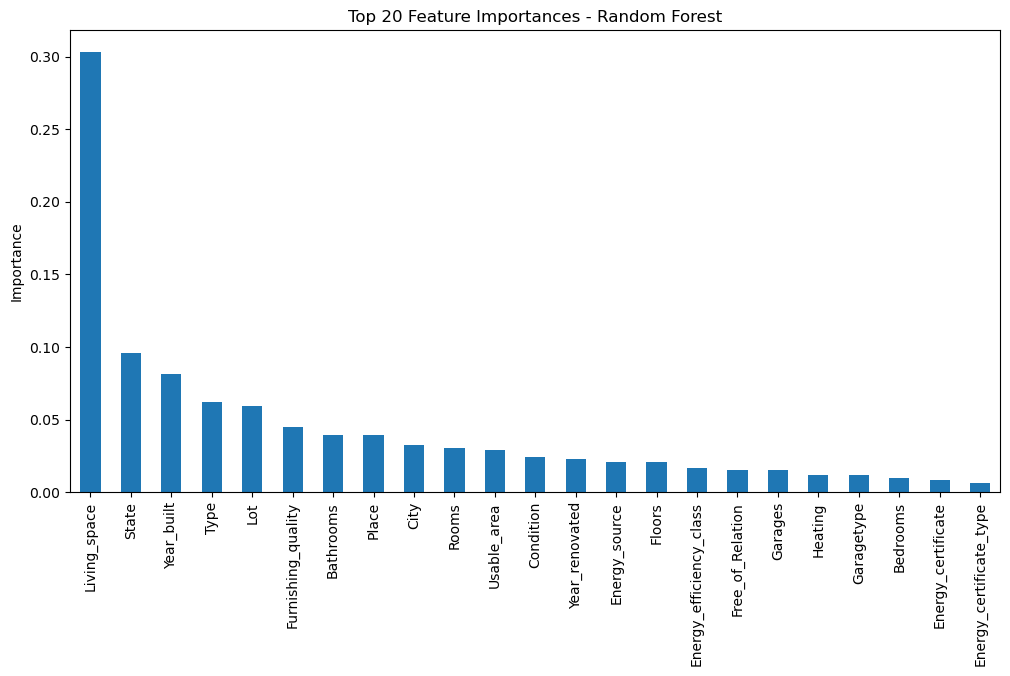

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import matplotlib.pyplot as plt

# Identify numeric and categorical columns
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Fill missing values
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_train[cat_cols] = X_train[cat_cols].fillna('Unknown')

# Ordinal encode categorical features
ordinal_encoder = OrdinalEncoder()
X_train[cat_cols] = ordinal_encoder.fit_transform(X_train[cat_cols])

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Show top 20 features
print("Top 20 features by importance:")
print(feature_importances.head(23))

# Plot top 20 features
plt.figure(figsize=(12,6))
feature_importances.head(23).plot(kind='bar')
plt.title("Top 20 Feature Importances - Random Forest")
plt.ylabel("Importance")
plt.show()


0:	learn: 577928.6979638	total: 157ms	remaining: 1m 18s
100:	learn: 346907.4908648	total: 527ms	remaining: 2.08s
200:	learn: 288834.9995649	total: 788ms	remaining: 1.17s
300:	learn: 250363.4308504	total: 1.13s	remaining: 746ms
400:	learn: 221493.3256769	total: 1.41s	remaining: 348ms
499:	learn: 199601.2079201	total: 1.67s	remaining: 0us
Top 20 features by importance:
Living_space               21.171955
State                      14.168150
Furnishing_quality         11.940548
City                       10.365842
Type                        6.897646
Lot                         6.222069
Year_built                  5.697405
Usable_area                 3.329278
Bathrooms                   2.635084
Condition                   2.514925
Rooms                       2.484923
Energy_source               2.202438
Place                       2.143281
Floors                      1.972533
Year_renovated              1.185729
Garagetype                  1.102366
Heating                     0.948291
G

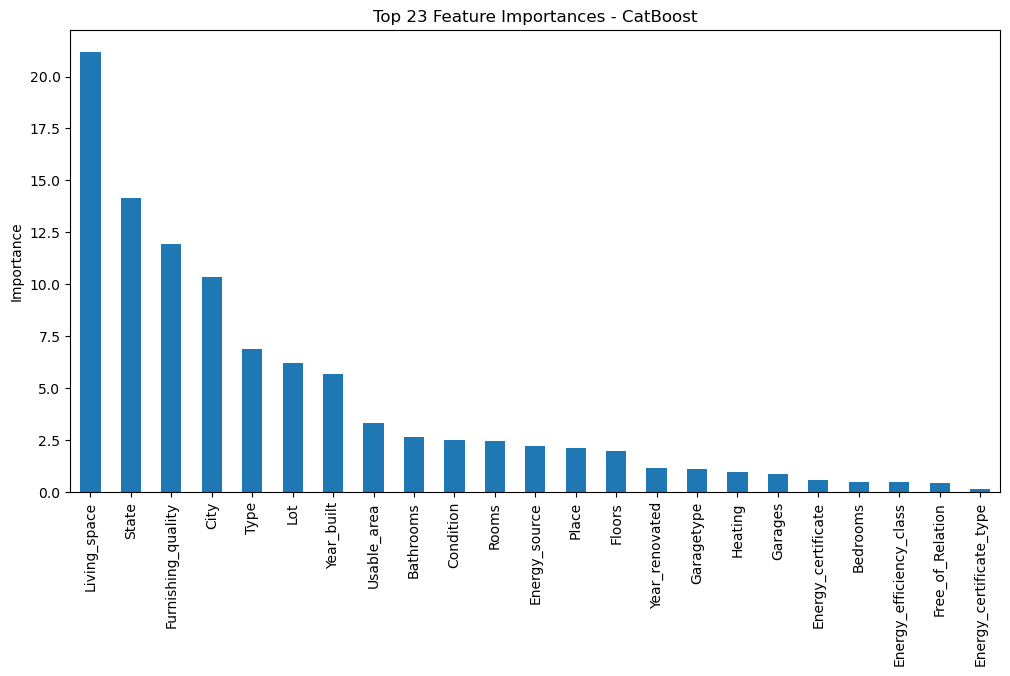

In [50]:
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt
import pandas as pd

# Identify categorical columns
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Fill numeric nulls with median (CatBoost can handle missing but better to fill for clarity)
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())

# CatBoost Pool (optional but recommended)
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_cols)

# Train CatBoost Regressor
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

cat_model.fit(train_pool)

# Get feature importances
feature_importances = pd.Series(cat_model.get_feature_importance(train_pool), index=X_train.columns).sort_values(ascending=False)

# Show top 20 features
print("Top 20 features by importance:")
print(feature_importances.head(23))

# Plot top 20 features
plt.figure(figsize=(12,6))
feature_importances.head(23).plot(kind='bar')
plt.title("Top 23 Feature Importances - CatBoost")
plt.ylabel("Importance")
plt.show()


In [65]:
pd.set_option('display.max_rows', 30)

# Show value counts for City including all
print(train_df['City'].value_counts(dropna=False))

City
Hannover (Kreis)                               86
Nordfriesland (Kreis)                          80
Wetteraukreis                                  73
Rhein-Neckar-Kreis                             67
Mayen-Koblenz (Kreis)                          64
Rhein-Sieg-Kreis                               60
Schleswig-Flensburg (Kreis)                    58
Gifhorn (Kreis)                                53
Bad Kreuznach (Kreis)                          52
Rendsburg-Eckernfrde (Kreis)                   52
Recklinghausen (Kreis)                         51
Karlsruhe (Kreis)                              49
Cuxhaven (Kreis)                               49
Lippe (Kreis)                                  49
Esslingen (Kreis)                              49
Mnchen                                         49
Oberhavel (Kreis)                              48
Havelland (Kreis)                              47
Mittelsachsen (Kreis)                          47
Ludwigsburg (Kreis)                          

In [85]:
city_counts = train_df['City'].value_counts()


def bin_city_kreis(city):
    if pd.isna(city):
        return 'Other'  
    city_str = str(city)

    if 'Kreis' in city_str:
        return 'District'
    elif city_counts.get(city_str, 0) > 50:
        return city_str
    elif city_counts.get(city_str, 0) > 10:
        return 'Other_major'
    else:
        return 'Other'


# 3. Apply to train and test (NO leakage)
train_df['City_binned'] = train_df['City'].apply(bin_city_kreis)
test_df['City_binned'] = test_df['City'].apply(bin_city_kreis)


In [89]:
train_df=train_df.drop(columns='City')
test_df=test_df.drop(columns='City')

In [76]:
cols_to_drop = [
    'Energy_efficiency_class',
    'Free_of_Relation',
    'Energy_certificate_type',
    'Usable_area',
    'Year_renovated',
    'Energy_certificate',
    'Bedrooms',
    'Bathrooms',
    'Garagetype',
    'Energy_source',
    'Place'  
]


train_df = train_df.drop(columns=cols_to_drop)
print("Train set columns after dropping: ",train_df.shape)

Train set columns after dropping:  (8207, 14)


In [79]:
test_df=test_df.drop(columns=cols_to_drop)

In [77]:
train_df.isnull().sum()

Price                    0
Type                   294
Living_space             0
Lot                      0
Rooms                    0
Floors                2095
Year_built             504
Furnishing_quality    2143
Condition              243
Heating                461
State                    0
City                     0
Garages               1439
City_binned              0
dtype: int64

In [78]:
train_df.dtypes

Price                 float64
Type                   object
Living_space          float64
Lot                   float64
Rooms                 float64
Floors                float64
Year_built            float64
Furnishing_quality     object
Condition              object
Heating                object
State                  object
City                   object
Garages               float64
City_binned            object
dtype: object

In [95]:
num_cols_with_nulls = [
    'Year_built','Floors', 'Garages'
]
cat_cols_with_nulls = [
    'Furnishing_quality', 'Type','Heating','Condition'
]

median_imputer = SimpleImputer(strategy='median')
train_df[num_cols_with_nulls] = median_imputer.fit_transform(train_df[num_cols_with_nulls])
test_df[num_cols_with_nulls] = median_imputer.transform(test_df[num_cols_with_nulls])

for col in cat_cols_with_nulls:
    train_df[col] = train_df[col].fillna('Unknown')
    test_df[col]=test_df[col].fillna("Unknown")

print("After handling nulls: ",train_df.shape)

After handling nulls:  (8207, 13)


In [98]:
num_cols = train_df.select_dtypes(include=['float64', 'int64']).columns

In [101]:
# scaling the numerical features
scaler = StandardScaler()

# fit on training data only
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])

# transform test data using the same scaler
test_df[num_cols] = scaler.transform(test_df[num_cols])

# Encoding

In [122]:
from sklearn.preprocessing import OneHotEncoder


# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train only
X_train_type = encoder.fit_transform(train_df[['Type']])
X_test_type = encoder.transform(test_df[['Type']])

# Convert to DataFrame with proper column names
X_train_type = pd.DataFrame(X_train_type, 
                            columns=encoder.get_feature_names_out(['Type']), 
                            index=train_df.index)
X_test_type = pd.DataFrame(X_test_type, 
                           columns=encoder.get_feature_names_out(['Type']), 
                           index=test_df.index)

# Merge back to original dataframes and drop original 'Type' column
train_df = pd.concat([train_df.drop(columns=['Type']), X_train_type], axis=1)
test_df = pd.concat([test_df.drop(columns=['Type']), X_test_type], axis=1)


In [117]:
furnish_map = {
    'Unknown': 0,
    'basic': 1,
    'normal': 2,
    'refined': 3,
    'luxus': 4
}

train_df['Furnishing_quality'] = train_df['Furnishing_quality'].map(furnish_map)
test_df['Furnishing_quality'] = test_df['Furnishing_quality'].map(furnish_map)

In [124]:


# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train only
X_train_type = encoder.fit_transform(train_df[['Condition']])
X_test_type = encoder.transform(test_df[['Condition']])

# Convert to DataFrame with proper column names
X_train_type = pd.DataFrame(X_train_type, 
                            columns=encoder.get_feature_names_out(['Condition']), 
                            index=train_df.index)
X_test_type = pd.DataFrame(X_test_type, 
                           columns=encoder.get_feature_names_out(['Condition']), 
                           index=test_df.index)

# Merge back to original dataframes and drop original 'Type' column
train_df = pd.concat([train_df.drop(columns=['Condition']), X_train_type], axis=1)
test_df = pd.concat([test_df.drop(columns=['Condition']), X_test_type], axis=1)


In [126]:


# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train only
X_train_type = encoder.fit_transform(train_df[['Heating']])
X_test_type = encoder.transform(test_df[['Heating']])

# Convert to DataFrame with proper column names
X_train_type = pd.DataFrame(X_train_type, 
                            columns=encoder.get_feature_names_out(['Heating']), 
                            index=train_df.index)
X_test_type = pd.DataFrame(X_test_type, 
                           columns=encoder.get_feature_names_out(['Heating']), 
                           index=test_df.index)

# Merge back to original dataframes and drop original 'Type' column
train_df = pd.concat([train_df.drop(columns=['Heating']), X_train_type], axis=1)
test_df = pd.concat([test_df.drop(columns=['Heating']), X_test_type], axis=1)


In [128]:


# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train only
X_train_type = encoder.fit_transform(train_df[['State']])
X_test_type = encoder.transform(test_df[['State']])

# Convert to DataFrame with proper column names
X_train_type = pd.DataFrame(X_train_type, 
                            columns=encoder.get_feature_names_out(['State']), 
                            index=train_df.index)
X_test_type = pd.DataFrame(X_test_type, 
                           columns=encoder.get_feature_names_out(['State']), 
                           index=test_df.index)

# Merge back to original dataframes and drop original 'Type' column
train_df = pd.concat([train_df.drop(columns=['State']), X_train_type], axis=1)
test_df = pd.concat([test_df.drop(columns=['State']), X_test_type], axis=1)


In [130]:


# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train only
X_train_type = encoder.fit_transform(train_df[['City_binned']])
X_test_type = encoder.transform(test_df[['City_binned']])

# Convert to DataFrame with proper column names
X_train_type = pd.DataFrame(X_train_type, 
                            columns=encoder.get_feature_names_out(['City_binned']), 
                            index=train_df.index)
X_test_type = pd.DataFrame(X_test_type, 
                           columns=encoder.get_feature_names_out(['City_binned']), 
                           index=test_df.index)

# Merge back to original dataframes and drop original 'Type' column
train_df = pd.concat([train_df.drop(columns=['City_binned']), X_train_type], axis=1)
test_df = pd.concat([test_df.drop(columns=['City_binned']), X_test_type], axis=1)


# Feature Selection

In [133]:
X_train_final = train_df.drop('Price', axis=1)
y_train_final = train_df['Price']

X_test_final = test_df.drop('Price', axis=1)
y_test_final = test_df['Price']

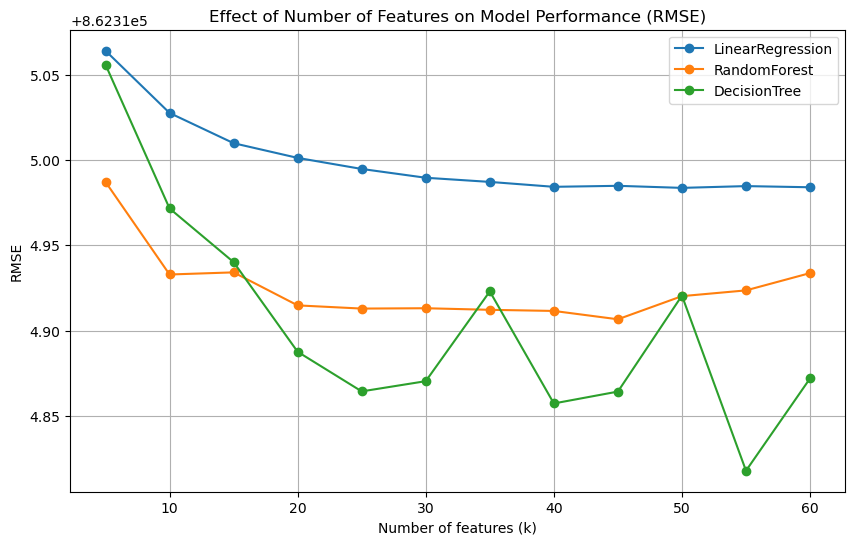

In [154]:
from sklearn.metrics import mean_squared_error

# Example models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42)
}

# Range of k values
k_values = list(range(5, min(61, X_train_final.shape[1])+1, 5))
results_rmse = {name: [] for name in models.keys()}

for k in k_values:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_train_k = selector.fit_transform(X_train_final, y_train_final)
    X_test_k = selector.transform(X_test_final)
    
    for name, model in models.items():
        model.fit(X_train_k, y_train_final)
        y_pred = model.predict(X_test_k)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        results_rmse[name].append(rmse)

# Plot RMSE curves
plt.figure(figsize=(10,6))
for name, scores in results_rmse.items():
    plt.plot(k_values, scores, marker='o', label=name)
plt.xlabel('Number of features (k)')
plt.ylabel('RMSE')
plt.title('Effect of Number of Features on Model Performance (RMSE)')
plt.legend()
plt.grid(True)
plt.show()


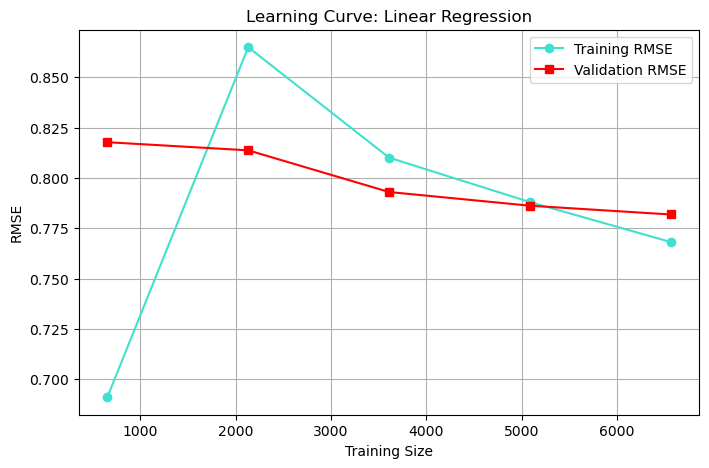

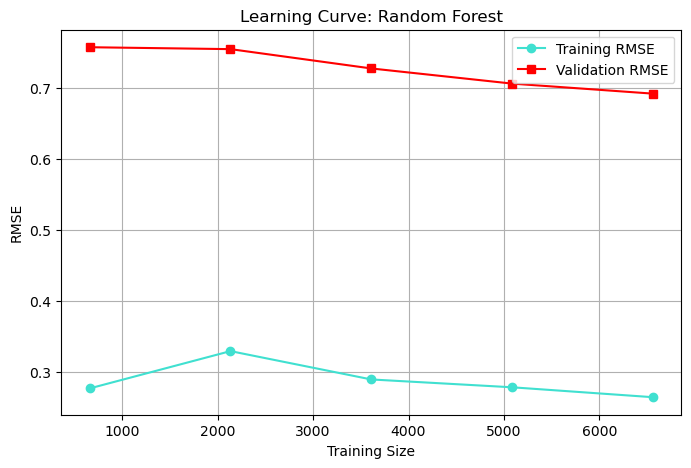

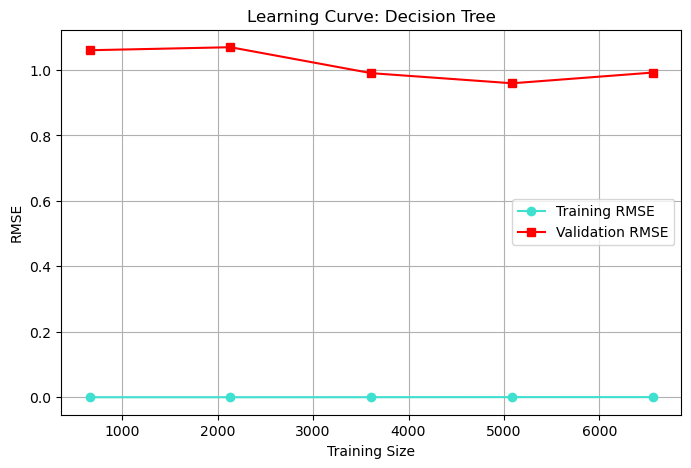

In [158]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve_regression(model, X, y, title, scoring='neg_root_mean_squared_error'):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring=scoring,      
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    
    # Convert negative RMSE to positive
    train_scores = -train_scores
    test_scores = -test_scores
    
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Training RMSE', color='turquoise')
    plt.plot(train_sizes, test_scores.mean(axis=1), marker='s', label='Validation RMSE', color='red')
    plt.xlabel("Training Size")
    plt.ylabel('RMSE')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage
plot_learning_curve_regression(LinearRegression(), X_train_final, y_train_final, "Learning Curve: Linear Regression")
plot_learning_curve_regression(RandomForestRegressor(n_estimators=100, random_state=42), X_train_final, y_train_final, "Learning Curve: Random Forest")
plot_learning_curve_regression(DecisionTreeRegressor(random_state=42), X_train_final, y_train_final, "Learning Curve: Decision Tree")


# Evaluation

In [163]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Initialize the model
lr_model = LinearRegression()

# Fit on training data
lr_model.fit(X_train_final, y_train_final)

# Predict on test data
y_pred = lr_model.predict(X_test_final)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression Performance on Test Set:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


Linear Regression Performance on Test Set:
R² Score: -0.7341
RMSE: 862314.9841
MAE: 561054.7140


In [227]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train_final, y_train_final)
y_pred_rf = rf_model.predict(X_test_final)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Performance on Test Set:")
print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}\n")


Random Forest Performance on Test Set:
R² Score: -0.7341
RMSE: 862314.9326
MAE: 561054.7193



In [228]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_final, y_train_final)
y_pred_dt = dt_model.predict(X_test_final)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Performance on Test Set:")
print(f"R² Score: {r2_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"MAE: {mae_dt:.4f}")

Decision Tree Performance on Test Set:
R² Score: -0.7341
RMSE: 862314.8761
MAE: 561054.7128
